# 04 — False-Positive & Error Analysis

**Objective:** understand *why* legitimate transactions get flagged as fraud (false positives) and *what kind* of fraud slips through (false negatives) - treated as a core modeling task, not just a false-positive-rate number, per the project's core focus on minimizing false positives.

Uses the Random Forest model at the Stage 5 operating threshold (0.12), on the validation split. Loads the persisted model/preprocessor from Stage 5/6 instead of retraining.

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

import preprocessing as pp

sns.set_style('whitegrid')
DATA_DIR = '../data'
MODELS_DIR = '../models'
THRESHOLD = 0.12

In [2]:
train_raw = pp.engineer_features(pp.load_raw(f'{DATA_DIR}/fraudTrain.csv'))
_, val_split = pp.temporal_train_val_split(train_raw, val_weeks=6)

X_val, y_val = pp.split_X_y(val_split)

preprocessor = joblib.load(f'{MODELS_DIR}/preprocessor.pkl')
rf_model = joblib.load(f'{MODELS_DIR}/random_forest.pkl')

Xt_val = preprocessor.transform(X_val)
risk_score = rf_model.predict_proba(Xt_val)[:, 1]
predicted = (risk_score >= THRESHOLD).astype(int)

print('Validation set:', len(val_split), 'transactions,', y_val.sum(), 'actual fraud')
print('Flagged at threshold', THRESHOLD, ':', predicted.sum())

Validation set: 111581 transactions, 669 actual fraud
Flagged at threshold 0.12 : 1139


## Build the error-analysis dataframe

In [3]:
err = val_split.reset_index(drop=True).copy()
err['risk_score'] = risk_score
err['predicted'] = predicted

def classify(row):
    if row['is_fraud'] == 1 and row['predicted'] == 1:
        return 'TP'
    if row['is_fraud'] == 0 and row['predicted'] == 1:
        return 'FP'
    if row['is_fraud'] == 1 and row['predicted'] == 0:
        return 'FN'
    return 'TN'

err['outcome'] = err.apply(classify, axis=1)
print(err['outcome'].value_counts())

outcome
TN    110387
TP       614
FP       525
FN        55
Name: count, dtype: int64


## False positives: are they concentrated among high-value transactions?

In [4]:
print(err.groupby('outcome')['amt'].describe()[['count', 'mean', '50%', 'std', 'max']])

            count        mean     50%         std       max
outcome                                                    
FN           55.0   93.675455   19.42  213.003900    939.56
FP          525.0  367.013524  111.60  528.148485   6438.07
TN       110387.0   66.219020   47.29  167.063049  27119.77
TP          614.0  583.706303  712.10  377.776047   1376.04


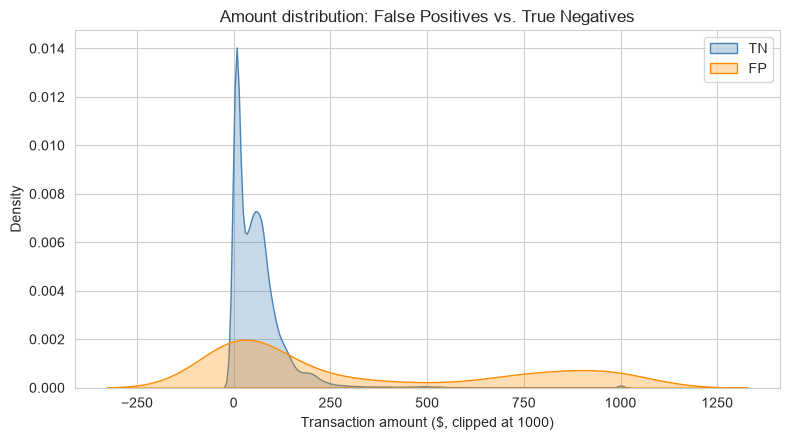

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for outcome, color in [('TN', 'steelblue'), ('FP', 'darkorange')]:
    sns.kdeplot(err.loc[err['outcome'] == outcome, 'amt'].clip(upper=1000), label=outcome, color=color, fill=True, alpha=0.3, ax=ax)
ax.set_xlabel('Transaction amount ($, clipped at 1000)')
ax.set_title('Amount distribution: False Positives vs. True Negatives')
ax.legend()
plt.tight_layout()
plt.show()

## False positives: concentrated in particular categories or time periods?

In [6]:
fp_rate_by_category = err.groupby('category').apply(
    lambda d: pd.Series({
        'n_legit': (d['is_fraud'] == 0).sum(),
        'n_fp': ((d['is_fraud'] == 0) & (d['predicted'] == 1)).sum(),
    }),
    include_groups=False,
)
fp_rate_by_category['fp_rate_pct'] = 100 * fp_rate_by_category['n_fp'] / fp_rate_by_category['n_legit']
fp_rate_by_category.sort_values('fp_rate_pct', ascending=False)

,n_legit,n_fp,fp_rate_pct
category,,,
grocery_net,3949,34,0.860977
shopping_net,8292,61,0.735649
misc_net,5500,40,0.727273
kids_pets,9695,68,0.701392
travel,3429,24,0.699913
personal_care,7796,51,0.654182
shopping_pos,10005,64,0.639680
misc_pos,6840,40,0.584795
food_dining,7736,38,0.491210


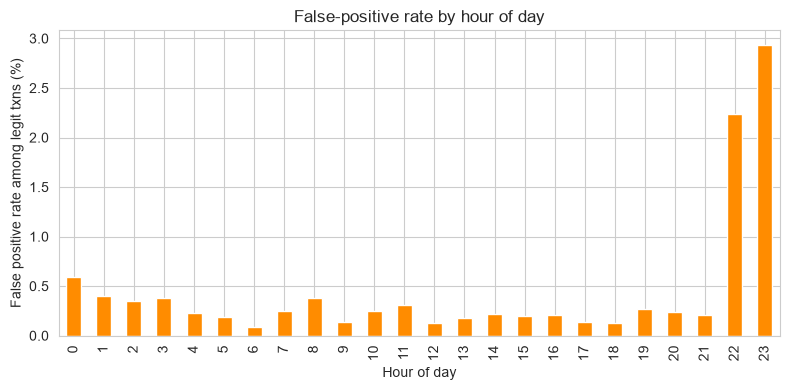

In [7]:
fp_by_hour = err.groupby('hour').apply(
    lambda d: pd.Series({
        'n_legit': (d['is_fraud'] == 0).sum(),
        'n_fp': ((d['is_fraud'] == 0) & (d['predicted'] == 1)).sum(),
    }),
    include_groups=False,
)
fp_by_hour['fp_rate_pct'] = 100 * fp_by_hour['n_fp'] / fp_by_hour['n_legit']

fig, ax = plt.subplots(figsize=(8, 4))
fp_by_hour['fp_rate_pct'].plot(kind='bar', ax=ax, color='darkorange')
ax.set_ylabel('False positive rate among legit txns (%)')
ax.set_xlabel('Hour of day')
ax.set_title('False-positive rate by hour of day')
plt.tight_layout()
plt.show()

## Which features distinguish FP from TN, and FP from TP?

In [8]:
compare_cols = ['amt', 'age', 'city_pop', 'merchant_distance_km', 'hour']
print('FP vs TN (why legit transactions get flagged):')
print(err[err['outcome'].isin(['FP', 'TN'])].groupby('outcome')[compare_cols].mean().round(2))
print()
print('FP vs TP (what makes a false alarm look like real fraud):')
print(err[err['outcome'].isin(['FP', 'TP'])].groupby('outcome')[compare_cols].mean().round(2))

FP vs TN (why legit transactions get flagged):
            amt    age  city_pop  merchant_distance_km   hour
outcome                                                      
FP       367.01  42.27  79808.23                 75.79  17.03
TN        66.22  46.04  87945.49                 76.15  12.78

FP vs TP (what makes a false alarm look like real fraud):
            amt    age  city_pop  merchant_distance_km   hour
outcome                                                      
FP       367.01  42.27  79808.23                 75.79  17.03
TP       583.71  50.25  33410.62                 76.80  14.35


## False negatives: what fraud does the model miss?

In [9]:
print('FN vs TP (missed fraud vs. caught fraud):')
print(err[err['outcome'].isin(['FN', 'TP'])].groupby('outcome')[compare_cols].mean().round(2))
print()
print('FN by category:')
print(err[err['outcome'].isin(['FN', 'TP'])].groupby(['category', 'outcome']).size().unstack(fill_value=0))

FN vs TP (missed fraud vs. caught fraud):
            amt    age  city_pop  merchant_distance_km   hour
outcome                                                      
FN        93.68  43.22  43751.76                 74.68  18.69
TP       583.71  50.25  33410.62                 76.80  14.35

FN by category:
outcome         FN   TP
category               
entertainment    0   18
food_dining      5    6
gas_transport    0   56
grocery_net      1    8
grocery_pos      0  144
health_fitness   8    9
home             2   16
kids_pets       11    9
misc_net         3   91
misc_pos         4   22
personal_care   14    8
shopping_net     0  151
shopping_pos     1   74
travel           6    2


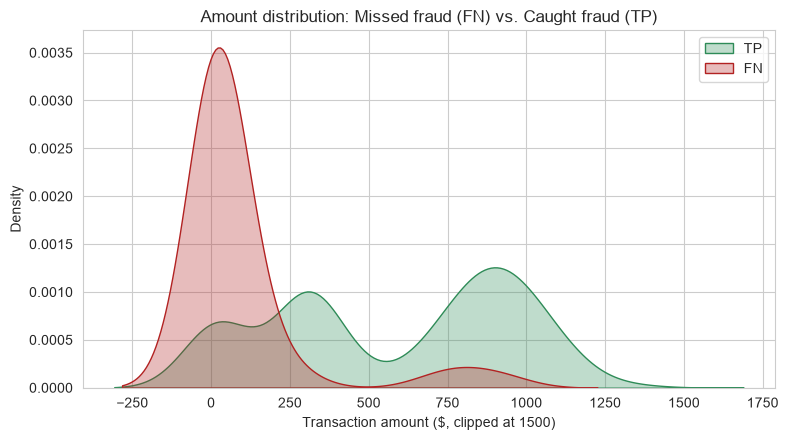

In [10]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for outcome, color in [('TP', 'seagreen'), ('FN', 'firebrick')]:
    sns.kdeplot(err.loc[err['outcome'] == outcome, 'amt'].clip(upper=1500), label=outcome, color=color, fill=True, alpha=0.3, ax=ax)
ax.set_xlabel('Transaction amount ($, clipped at 1500)')
ax.set_title('Amount distribution: Missed fraud (FN) vs. Caught fraud (TP)')
ax.legend()
plt.tight_layout()
plt.show()

## How does the threshold affect the error mix?

Comparing the Stage 5 operating threshold (0.12) against a stricter one (0.5, the naive default) and the near-tied XGBoost threshold (0.68) for reference - not to re-litigate Stage 5's choice, but to show concretely how the FP/FN balance shifts.

In [11]:
for t in [0.12, 0.5, 0.9]:
    pred_t = (risk_score >= t).astype(int)
    tp = int(((y_val == 1) & (pred_t == 1)).sum())
    fp = int(((y_val == 0) & (pred_t == 1)).sum())
    fn = int(((y_val == 1) & (pred_t == 0)).sum())
    tn = int(((y_val == 0) & (pred_t == 0)).sum())
    print(f'threshold={t:.2f}  TP={tp:4d}  FP={fp:4d}  FN={fn:4d}  TN={tn:6d}')

threshold=0.12  TP= 614  FP= 525  FN=  55  TN=110387
threshold=0.50  TP= 560  FP=  57  FN= 109  TN=110855
threshold=0.90  TP= 392  FP=   2  FN= 277  TN=110910


## Summary of error-analysis findings

At threshold 0.12: 614 true positives, 525 false positives, 55 false negatives, 110,387 true negatives.

**False positives ARE concentrated among higher-value transactions:** mean amount $367.01 (median $111.60) vs. $66.22 (median $47.29) for true negatives - confirming the pattern the project plan asked us to check for, not just assumed.

**False positives cluster in card-not-present-style categories:** `grocery_net` (0.86% FP rate), `shopping_net` (0.74%), `misc_net` (0.73%), `kids_pets` (0.70%), and `travel` (0.70%) have the highest false-positive rates, while `grocery_pos` (0.09%) and `gas_transport` (0.13%) have the lowest. This lines up with Stage 1's EDA finding that these same online (`_net`) categories carry the highest real fraud rates - the model is picking up a genuine category-level signal, it's just not perfectly precise about it.

**FP vs. TN:** false positives skew toward higher amounts, later hours (17.0 vs. 12.8 average), and lower `city_pop` - i.e., legitimate transactions that *look* like fraud on the features the model uses. `merchant_distance_km` shows no separation here either (75.8 vs. 76.2), consistent with Stage 1.

**FP vs. TP:** false positives are high-amount but not *as* high as real fraud ($367 vs. $584 mean), and occur in noticeably denser areas (`city_pop` 79,808 vs. 33,410) - genuine fraud in this dataset skews toward less populous areas, a pattern the model has partly learned but doesn't fully separate on amount and city_pop alone.

**What fraud does the model miss (FN vs. TP):** missed fraud is dramatically lower-amount ($93.68 vs. $583.71 mean) and skews later in the day (18.7 vs. 14.4 average hour). By category, the model has perfect or near-perfect recall on `grocery_pos`, `shopping_net`, `gas_transport`, and `entertainment` (0 missed each), but actually **misses more fraud than it catches** in `kids_pets` (11 FN vs. 9 TP), `personal_care` (14 FN vs. 8 TP), and `travel` (6 FN vs. 2 TP) - all lower-typical-amount categories. The model has effectively learned 'high amount + certain categories = fraud' and is weakest exactly where fraud doesn't announce itself with a large amount.

**Threshold sensitivity, in raw counts:** at 0.12, 525 FPs buy 614 TPs (55 FN); at 0.50, FPs drop to 57 but FN nearly doubles to 109; at 0.90, FPs nearly vanish (2) but FN triples to 277. There's no threshold that removes both kinds of error - Stage 5's choice of 0.12 explicitly accepts more false positives (mostly higher-value, explainable-looking transactions) in exchange for catching fraud that a stricter threshold would let through, particularly the lower-amount fraud this section shows the model already struggles with.

**Implication for Stage 9 (fraud rules):** amount and category are real, usable signals for investigator-facing rules; `merchant_distance_km` is not, on this dataset (confirmed twice now, in EDA and here). A simple 'flag if amount is unusually high for this category' rule would catch much of what the model catches, but would inherit the same blind spot on low-amount fraud.

## Stage 8 — Model Explainability

Unlike the anonymized `V1`-`V28` PCA features in the original 2019 iteration of this project, every feature here is genuinely interpretable (amount, category, age, city population, hour, day of week, merchant distance) - so SHAP explanations translate directly into investigator-facing reasoning, not just abstract component numbers. Using SHAP's `TreeExplainer` on the Random Forest carried forward from Stage 5.

A quick timing check showed exact SHAP on this Random Forest (100 trees, unbounded depth) costs roughly 0.2s/row - fine for individual explanations, too slow for the full 111k-row validation set. The global summary below uses a stratified sample (200 fraud + 200 legitimate) rather than the full set.

In [12]:
import shap

feature_names = pp.get_feature_names(preprocessor)
Xt_val_dense = Xt_val.toarray() if hasattr(Xt_val, 'toarray') else Xt_val

rng = np.random.default_rng(42)
fraud_idx = np.where(y_val.values == 1)[0]
legit_idx = np.where(y_val.values == 0)[0]
sample_idx = np.concatenate([
    rng.choice(fraud_idx, size=200, replace=False),
    rng.choice(legit_idx, size=200, replace=False),
])
X_shap_sample = Xt_val_dense[sample_idx]

explainer = shap.TreeExplainer(rf_model)
shap_values_all = explainer.shap_values(X_shap_sample)
shap_fraud = shap_values_all[:, :, 1]  # contributions toward the fraud class
print('SHAP values shape (samples, features):', shap_fraud.shape)

SHAP values shape (samples, features): (400, 28)


### Global feature importance

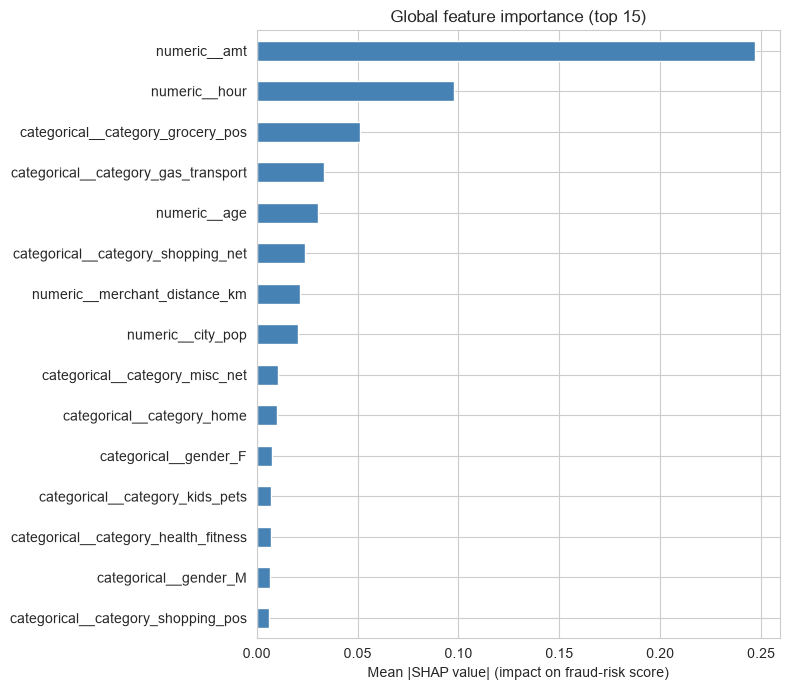

In [13]:
mean_abs_shap = pd.Series(np.abs(shap_fraud).mean(axis=0), index=feature_names)
mean_abs_shap = mean_abs_shap.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 7))
mean_abs_shap.tail(15).plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Mean |SHAP value| (impact on fraud-risk score)')
ax.set_title('Global feature importance (top 15)')
plt.tight_layout()
plt.show()

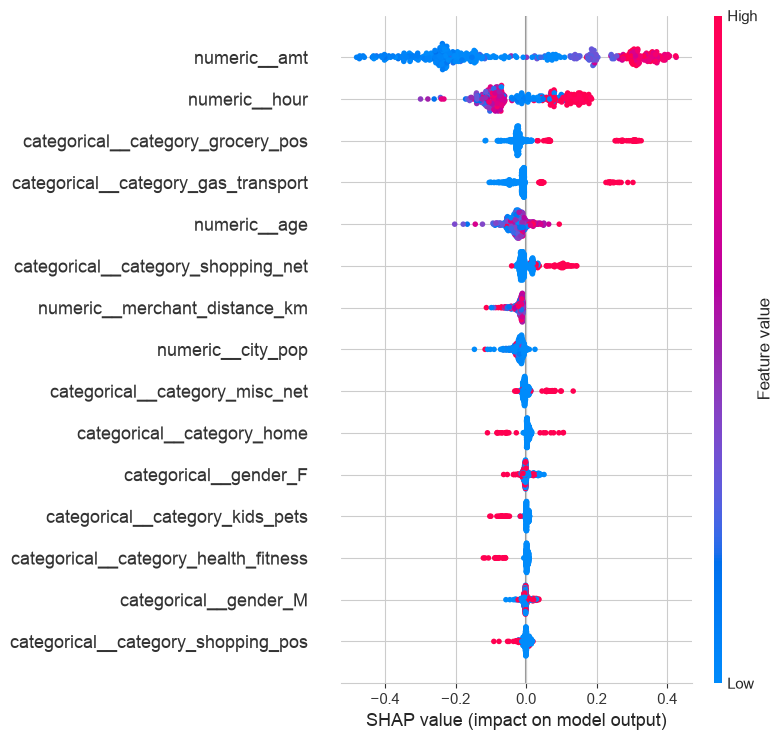

In [14]:
shap.summary_plot(shap_fraud, X_shap_sample, feature_names=feature_names, show=False, max_display=15)
plt.tight_layout()
plt.show()

### Global explainability takeaway

Mean |SHAP value| ranking (top features, out of 28):

| Feature | Mean \|SHAP\| |
|---|---|
| `amt` | 0.2470 |
| `hour` | 0.0979 |
| `category = grocery_pos` | 0.0513 |
| `category = gas_transport` | 0.0332 |
| `age` | 0.0302 |
| `category = shopping_net` | 0.0241 |
| `merchant_distance_km` | 0.0212 |
| `city_pop` | 0.0207 |

**Amount dominates** - its SHAP contribution is 2.5x the next-highest feature (`hour`) and 5x the largest single category indicator. This confirms, quantitatively, what Stage 7's error analysis found by comparing raw distributions: the model has essentially learned an amount-driven decision rule with category and time-of-day as secondary adjustments.

`merchant_distance_km` lands 7th out of 28 - not zero, but its contribution (0.021) is roughly a tenth of `amt`'s. So while Stage 1 and Stage 7 both found no separation in the *raw distribution* of this feature between fraud and legitimate transactions, the model still extracts a small amount of signal from it in combination with other features (that's the nature of tree-based interactions SHAP can surface that a univariate distribution comparison can't). It remains a weak, secondary feature either way - the Stage 9 caution against building a standalone geographic-anomaly rule on it stands.

## Individual alert explainability

For a handful of specific transactions - the top true positives (highest-risk correctly-caught fraud), plus one false negative (missed fraud) - show the risk score, prediction, actual label, and the features that pushed the score up or down the most.

In [15]:
def explain_row(position, label):
    row_shap = explainer.shap_values(Xt_val_dense[position:position + 1])[:, :, 1][0]
    contributions = pd.Series(row_shap, index=feature_names).sort_values(key=abs, ascending=False)
    print(f'--- {label} (row {position}) ---')
    print('Risk score:', round(err.loc[position, "risk_score"], 4))
    print('Predicted: ', 'Fraud' if err.loc[position, 'predicted'] == 1 else 'Legitimate')
    print('Actual:    ', 'Fraud' if err.loc[position, 'is_fraud'] == 1 else 'Legitimate')
    print('Amount: $', err.loc[position, 'amt'], ' | Category:', err.loc[position, 'category'])
    print('Top contributing features (feature=value, SHAP contribution):')
    for feat, contrib in contributions.head(6).items():
        print(f'  {feat:35s} shap={contrib:+.4f}')
    print()

top_tp_positions = err[err['outcome'] == 'TP'].sort_values('risk_score', ascending=False).index[:3]
for pos in top_tp_positions:
    explain_row(pos, 'High-risk true positive')

top_fn_position = err[err['outcome'] == 'FN'].sort_values('risk_score', ascending=False).index[0]
explain_row(top_fn_position, 'Highest-scoring false negative (still missed)')

--- High-risk true positive (row 61632) ---
Risk score: 1.0
Predicted:  Fraud
Actual:     Fraud
Amount: $ 902.11  | Category: shopping_pos
Top contributing features (feature=value, SHAP contribution):
  numeric__amt                        shap=+0.3889
  numeric__hour                       shap=+0.1655
  categorical__category_grocery_pos   shap=-0.0271
  numeric__city_pop                   shap=-0.0205
  categorical__category_shopping_net  shap=-0.0194
  numeric__merchant_distance_km       shap=-0.0147

--- High-risk true positive (row 50431) ---
Risk score: 1.0
Predicted:  Fraud
Actual:     Fraud
Amount: $ 280.8  | Category: grocery_pos
Top contributing features (feature=value, SHAP contribution):
  categorical__category_grocery_pos   shap=+0.2674
  numeric__amt                        shap=+0.1359
  numeric__hour                       shap=+0.0712
  numeric__age                        shap=-0.0357
  categorical__category_shopping_net  shap=+0.0244
  categorical__gender_F               

--- Highest-scoring false negative (still missed) (row 4659) ---
Risk score: 0.11
Predicted:  Legitimate
Actual:     Fraud
Amount: $ 145.21  | Category: food_dining
Top contributing features (feature=value, SHAP contribution):
  numeric__amt                        shap=-0.2500
  numeric__hour                       shap=+0.1019
  categorical__category_food_dining   shap=-0.0470
  categorical__day_of_week_Monday     shap=-0.0419
  numeric__merchant_distance_km       shap=-0.0321
  numeric__age                        shap=-0.0301



### Individual explainability takeaway

All three highest-risk true positives scored a **risk score of 1.0** (every tree in the forest agreed) - two were `grocery_pos` transactions where the category itself was the dominant push toward fraud (SHAP +0.27 and +0.29), the third was a $902 `shopping_pos` transaction where amount alone contributed +0.39. In each case, `hour` added a smaller positive push, and being a *different* category (e.g. `grocery_pos` or `shopping_net` indicators showing up negatively on rows where they don't apply) pulled the score down slightly - exactly the kind of reasoning an investigator could act on directly: *'flagged because it's a grocery_pos transaction at an unusual hour.'*

The missed fraud case is the more instructive one: a $145.21 `food_dining` transaction scored only 0.11 (well under the 0.12 threshold), and **amount was the single largest reason it wasn't flagged** (SHAP -0.25 - the model saw this amount as looking *legitimate*). This is the same blind spot Stage 7 already surfaced in aggregate (missed fraud averages $94 vs. $584 for caught fraud) - here it's visible in a single concrete transaction, with the exact feature responsible. No amount of threshold tuning fixes this: the model needs a signal other than amount to catch low-value fraud, and on this dataset (per Stage 1 and this section) the interpretable features available don't offer one strongly enough.

## Stage 9 — Fraud Rules

Because this dataset has genuinely interpretable features (unlike the anonymized `V1`-`V28` PCA features in the original 2019 iteration), simple, investigator-explainable rules are actually possible here. Four candidates, each tied to a finding from earlier stages:

1. **Unusual amount for this cardholder** - flag if a transaction's amount is more than 3 standard deviations above *that specific card's* historical average (profile built from train only). Motivated by Stage 7/8: amount is by far the strongest signal, but a global amount threshold ignores that $500 is unremarkable for one cardholder and highly unusual for another.
2. **Odd-hour transaction** - flag if hour is between midnight and 4am. Motivated by Stage 1/8: hour is the second-most important feature.
3. **Transaction velocity** - flag if this card has 3+ transactions within the past hour. A classic fraud-detection rule, not yet tested on this data.
4. **Geographic anomaly** - flag if merchant distance exceeds the 95th percentile (train). Included specifically to test - not assume - the Stage 1/7/8 finding that merchant distance carries no real signal here.

Rules are built from train-only statistics and evaluated on the validation set, exactly like the model.

In [16]:
train_split, _ = pp.temporal_train_val_split(train_raw, val_weeks=6)

cc_profile = train_split.groupby('cc_num')['amt'].agg(['mean', 'std']).rename(
    columns={'mean': 'cc_mean_amt', 'std': 'cc_std_amt'}
)
global_mean_amt, global_std_amt = train_split['amt'].mean(), train_split['amt'].std()
dist_p95 = train_split['merchant_distance_km'].quantile(0.95)

rules_df = val_split.reset_index(drop=True).merge(cc_profile, on='cc_num', how='left')
rules_df['cc_mean_amt'] = rules_df['cc_mean_amt'].fillna(global_mean_amt)
rules_df['cc_std_amt'] = rules_df['cc_std_amt'].fillna(global_std_amt).replace(0, global_std_amt)
rules_df['amt_zscore'] = (rules_df['amt'] - rules_df['cc_mean_amt']) / rules_df['cc_std_amt']

rules_df = rules_df.sort_values(['cc_num', 'trans_date_trans_time'])
velocity = (
    rules_df.set_index('trans_date_trans_time')
    .groupby('cc_num')['amt'].rolling('1h').count()
    .reset_index(level=0, drop=True)
)
rules_df['velocity_1h'] = velocity.values
rules_df = rules_df.sort_index()

rules_df['rule_unusual_amt'] = rules_df['amt_zscore'] > 3
rules_df['rule_odd_hour'] = rules_df['hour'].isin([0, 1, 2, 3, 4])
rules_df['rule_velocity'] = rules_df['velocity_1h'] >= 3
rules_df['rule_geo'] = rules_df['merchant_distance_km'] > dist_p95

print(f'Cardholder profiles from train: {len(cc_profile)} unique cards, '
      f'{rules_df["cc_num"].isin(cc_profile.index).mean()*100:.2f}% of validation rows covered')
print('Merchant-distance p95 (train):', round(dist_p95, 1), 'km')

Cardholder profiles from train: 978 unique cards, 99.96% of validation rows covered
Merchant-distance p95 (train): 120.5 km


In [17]:
total_fraud = rules_df['is_fraud'].sum()
n_val = len(rules_df)

rule_specs = [
    ('Unusual amount (z > 3)', 'rule_unusual_amt'),
    ('Odd hour (midnight-4am)', 'rule_odd_hour'),
    ('Velocity (>=3 txns/hr)', 'rule_velocity'),
    ('Geographic anomaly (>p95 distance)', 'rule_geo'),
]

rows = []
for label, col in rule_specs:
    flagged = rules_df[col]
    n = int(flagged.sum())
    tp = int((flagged & (rules_df['is_fraud'] == 1)).sum())
    rows.append({
        'rule': label,
        'n_flagged': n,
        'pct_flagged': round(100 * n / n_val, 2),
        'precision': round(tp / n, 4) if n else 0.0,
        'recall': round(tp / total_fraud, 4),
    })

combined = rules_df['rule_unusual_amt'] | rules_df['rule_odd_hour'] | rules_df['rule_velocity']
n_c = int(combined.sum())
tp_c = int((combined & (rules_df['is_fraud'] == 1)).sum())
rows.append({
    'rule': 'Combined (amount + hour + velocity, OR)',
    'n_flagged': n_c,
    'pct_flagged': round(100 * n_c / n_val, 2),
    'precision': round(tp_c / n_c, 4),
    'recall': round(tp_c / total_fraud, 4),
})

rules_summary = pd.DataFrame(rows).set_index('rule')
rules_summary

,n_flagged,pct_flagged,precision,recall
rule,,,,
Unusual amount (z > 3),1689,1.51,0.2084,0.5262
Odd hour (midnight-4am),18209,16.32,0.0112,0.3049
Velocity (>=3 txns/hr),2538,2.27,0.0481,0.1824
Geographic anomaly (>p95 distance),5651,5.06,0.0065,0.0553
"Combined (amount + hour + velocity, OR)",21917,19.64,0.0244,0.7982


### How much do the rules add on top of the model?

In [18]:
rules_df['predicted_model'] = err['predicted'].values
missed_by_model = (rules_df['predicted_model'] == 0) & (rules_df['is_fraud'] == 1)
print('Fraud missed by the model (FN):', int(missed_by_model.sum()))

for label, col in rule_specs:
    recovered = int((missed_by_model & rules_df[col]).sum())
    print(f'{label:38s} recovers {recovered:2d} of {int(missed_by_model.sum())} model-missed fraud cases')

Fraud missed by the model (FN): 55
Unusual amount (z > 3)                 recovers  4 of 55 model-missed fraud cases
Odd hour (midnight-4am)                recovers  3 of 55 model-missed fraud cases
Velocity (>=3 txns/hr)                 recovers  9 of 55 model-missed fraud cases
Geographic anomaly (>p95 distance)     recovers  5 of 55 model-missed fraud cases


### Stage 9 takeaway

| Rule | % flagged | Precision | Recall |
|---|---|---|---|
| Unusual amount (z > 3, per cardholder) | 1.51% | **20.8%** | 52.6% |
| Odd hour (midnight-4am) | 16.32% | 1.1% | 30.5% |
| Velocity (>=3 txns/hr) | 2.27% | 4.8% | 18.2% |
| Geographic anomaly (>p95 distance) | 5.06% | 0.65% | 5.5% |
| Combined (amount OR hour OR velocity) | 19.64% | 2.4% | 79.8% |

**Unusual amount for this specific cardholder is a genuinely strong rule on its own** - 20.8% precision and 52.6% recall from one line of logic, with no model at all. It's the clear standout, consistent with amount dominating the SHAP importance ranking in Stage 8.

**Geographic anomaly is confirmed useless a third time** - not just no separation (Stage 1) and near-zero SHAP contribution relative to amount (Stage 8), but a standalone rule on it (0.65% precision) performs *worse than the 0.58% base fraud rate* would predict from random flagging. This is now conclusively established across three independent checks, not a one-off observation.

**Odd-hour and combined rules illustrate exactly why naive rules don't replace a model:** OR-ing three rules together reaches 79.8% recall - comparable to the model's 91.8% at threshold 0.12 - but by flagging **19.64% of all transactions** (nearly 1 in 5) rather than the model's 1.02%. No investigator team could operate at that volume; this is the concrete cost of precision that hand-written rules pay versus a trained ranking model.

**Do rules add anything on top of the model?** Of the 55 fraud cases the model misses (FN), the four rules together recover 16 (29%) - velocity alone recovers the most (9), more than the otherwise-stronger unusual-amount rule (4), because it's a genuinely different signal (transaction burst timing) orthogonal to what the model already leans on (amount and category). That's the real case for rules here: not as a replacement, but as a cheap, explainable **second check** layered on top of the model - specifically velocity, which catches a meaningfully different slice of fraud than the model's own blind spot. Geographic-anomaly rules are not worth building for this dataset; unusual-amount and odd-hour rules mostly duplicate what the model (via amount and hour, per Stage 8's SHAP ranking) already catches.

## Stage 10 — Monitoring & Drift

**This is the first time `fraudTest.csv` is used anywhere in this project.** Every prior stage (model selection, threshold choice, error analysis, SHAP, fraud rules) used only the validation split, exactly as planned in Stage 2. Simulating a monitoring system is the natural, appropriate place to finally touch it: replaying `fraudTest.csv` as consecutive weekly batches is both a monitoring simulation *and* the project's real final-generalization check - does the chosen model (Random Forest, threshold 0.12) actually hold up on transactions it has never influenced any decision about?

`src/monitoring.py` provides `monitor()` (per-batch fraud performance + operational load + drift) built on two lightweight drift checks: **PSI** for the risk-score distribution and a **KS test** for the amount distribution - each batch compared against the validation set the model was tuned on, not against other batches.

In [19]:
import monitoring as mon
import evaluate as ev
import warnings

test_raw = pp.engineer_features(pp.load_raw(f'{DATA_DIR}/fraudTest.csv'))
test_risk = rf_model.predict_proba(preprocessor.transform(pp.split_X_y(test_raw)[0]))[:, 1]
test_with_scores = test_raw.copy()
test_with_scores['risk_score'] = test_risk
print('Test set:', len(test_raw), 'transactions,', int(test_raw['is_fraud'].sum()), 'actual fraud')

Test set: 555719 transactions, 2145 actual fraud


### Does the model generalize to genuinely unseen future data?

Overall performance on the full test set (555,719 transactions, 2020-06-21 to 2020-12-31), threshold 0.12, vs. the validation numbers this threshold was chosen on.

In [20]:
test_pred = (test_risk >= THRESHOLD).astype(int)
test_overall = ev.fraud_metrics(test_raw['is_fraud'], test_pred, test_risk)

comparison = pd.DataFrame({
    'validation (Stage 5)': {'precision': 0.539, 'recall': 0.918, 'fpr': 0.0047},
    'test (held out)': {
        'precision': round(test_overall['precision'], 4),
        'recall': round(test_overall['recall'], 4),
        'fpr': round(test_overall['fpr'], 4),
    },
})
print('PR-AUC on test:', round(test_overall['pr_auc'], 4), ' ROC-AUC on test:', round(test_overall['roc_auc'], 4))
comparison

PR-AUC on test: 0.8767  ROC-AUC on test: 0.9868


,validation (Stage 5),test (held out)
precision,0.5390,0.4235
recall,0.9180,0.9091
fpr,0.0047,0.0048


### Batch-by-batch monitoring simulation (weekly)

In [21]:
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')

batch_report = mon.monitor(
    test_with_scores, y_true_col='is_fraud', proba_col='risk_score', amt_col='amt',
    threshold=THRESHOLD, reference_risk_scores=risk_score, reference_amt=val_split['amt'].values,
    freq='W',
)
print(f'{len(batch_report)} weekly batches, {batch_report["n_transactions"].sum():,} transactions total')
batch_report[['n_transactions', 'pct_flagged', 'observed_fraud_rate_pct', 'precision', 'recall', 'pr_auc']].round(4)

29 weekly batches, 555,719 transactions total


,n_transactions,pct_flagged,observed_fraud_rate_pct,precision,recall,pr_auc
batch,,,,,,
2020-06-15/2020-06-21,2028,1.1341,0.4931,0.3478,0.8000,0.8254
2020-06-22/2020-06-28,20029,0.7739,0.3145,0.3677,0.9048,0.8727
2020-06-29/2020-07-05,19995,0.8752,0.5101,0.5371,0.9216,0.8828
2020-07-06/2020-07-12,20146,0.9084,0.4467,0.4590,0.9333,0.9091
2020-07-13/2020-07-19,19792,0.6821,0.3032,0.3778,0.8500,0.8454
2020-07-20/2020-07-26,19918,1.0041,0.4418,0.4100,0.9318,0.9082
2020-07-27/2020-08-02,19754,0.7593,0.3139,0.3933,0.9516,0.9164
2020-08-03/2020-08-09,20019,1.0690,0.7393,0.5981,0.8649,0.8795
2020-08-10/2020-08-16,19523,0.8503,0.3995,0.4036,0.8590,0.8145


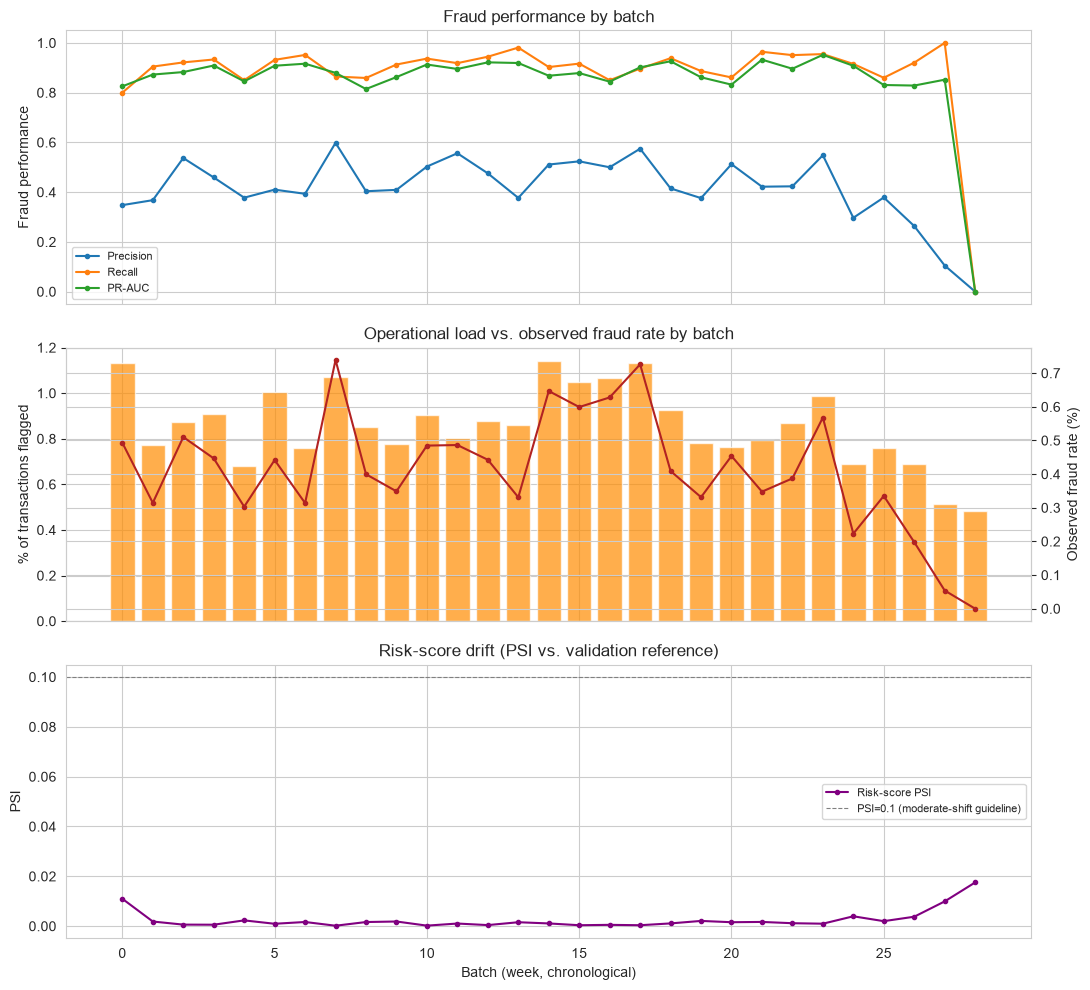

In [22]:
fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True)
x = range(len(batch_report))

axes[0].plot(x, batch_report['precision'], label='Precision', marker='o', markersize=3)
axes[0].plot(x, batch_report['recall'], label='Recall', marker='o', markersize=3)
axes[0].plot(x, batch_report['pr_auc'], label='PR-AUC', marker='o', markersize=3)
axes[0].set_ylabel('Fraud performance')
axes[0].legend(fontsize=8)
axes[0].set_title('Fraud performance by batch')

axes[1].bar(x, batch_report['pct_flagged'], color='darkorange', alpha=0.7, label='% flagged')
ax1b = axes[1].twinx()
ax1b.plot(x, batch_report['observed_fraud_rate_pct'], color='firebrick', marker='o', markersize=3, label='Observed fraud rate %')
axes[1].set_ylabel('% of transactions flagged')
ax1b.set_ylabel('Observed fraud rate (%)')
axes[1].set_title('Operational load vs. observed fraud rate by batch')

axes[2].plot(x, batch_report['risk_score_psi'], color='purple', marker='o', markersize=3, label='Risk-score PSI')
axes[2].axhline(0.1, color='gray', linestyle='--', linewidth=0.8, label='PSI=0.1 (moderate-shift guideline)')
axes[2].set_ylabel('PSI')
axes[2].set_xlabel('Batch (week, chronological)')
axes[2].set_title('Risk-score drift (PSI vs. validation reference)')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

### Stage 10 takeaway

**The model generalizes to genuinely unseen future data, with some honest degradation:**

| Metric | Validation (Stage 5) | Test (held out, first use) |
|---|---|---|
| Precision | 0.539 | 0.424 |
| Recall | 0.918 | 0.909 |
| FPR | 0.0047 | 0.0048 |
| PR-AUC | 0.913 (Stage 4, default threshold) | 0.877 |

Recall and FPR barely move - the model still catches ~91% of fraud while flagging legitimate transactions at essentially the same rate it did during tuning. Precision drops meaningfully (54% -> 42%), meaning a larger share of alerts on genuinely new data are false positives than the validation numbers suggested. This is a realistic, not cherry-picked, generalization result and belongs directly in the Stage 13 README limitations section: **validation-set metrics somewhat overstate real-world precision.**

**No meaningful drift across 6.5 months of test data:** risk-score PSI stayed between 0.0002 and 0.0175 across all 29 weekly batches - an order of magnitude under the 0.1 moderate-shift guideline. The amount distribution (KS test) was mostly not significantly different from the validation reference (p > 0.05 in most weeks), with one notable exception: the very first (partial) week showed a real amount-distribution shift (KS stat 0.107, p < 0.0001) - plausibly just an artifact of that batch being a partial week (only 2,028 transactions, vs. ~16,000-32,000 in full weeks) rather than genuine drift.

**Two things worth flagging honestly, not smoothing over:**
- Precision degrades in the final two full weeks of December (0.264 and 0.297, vs. a typical 0.40-0.55) - the observed fraud rate also drops sharply in that window (0.20-0.05%, less than half the typical ~0.4-0.5%), so this reads as a genuine seasonal dip in fraud rate (holiday shopping patterns changing the legitimate-transaction mix) rather than a model failure - exactly the kind of pattern this monitoring setup exists to surface.
- The final batch (2020-12-28 to 2021-01-03) has **zero observed fraud** and therefore undefined precision/recall/PR-AUC (shown as 0.0, not a real score) - it's a partial 4-day tail at the very end of the dataset, not a real performance collapse. A production monitoring dashboard should suppress or flag fraud-metric cards when a batch has zero positive cases, rather than display a misleading zero.